## Teoría de Juegos Evolutivos en Poblaciones de Guppies

#### Librerías

In [2]:
from os import remove
import os
import random
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt

---

### Parámetros Biológicos

In [3]:
#parámetros utilizados 
#Reproducción y Muerte
s_a = 0.8; s_b = 0.03; d_a = 0.107; d_b = 0.023 # Valores NO arbitrarios sacados de [4] y [7]
mu = 1e-6

---

#### Elementos Gráficos y Cod para Gráficas

In [4]:
colors = plt.cm.viridis([ 0.35, 0.45, 0.55, 0.65, 0.75, 0.85,0.95])
#Limpiamos La carpeta de gráficas para que no se acumulen las imágenes cuando las renombremos o algo así
for item in os.listdir('../Gráficas'):
    if item.endswith('.png'):
        remove(os.path.join('../Gráficas', item))

In [5]:
def plot(tamanio, p, legendname, tittle, xlabel, ylabel, save_name, process_func, **kwargs):
    fig, ax = plt.subplots(figsize=tamanio)
    
    for prop, color in zip(p, colors):
        generaciones = process_func(p=prop, **kwargs)[1]
        x = np.arange(len(generaciones))
        ax.plot(x, generaciones, label=fr'$p = {prop}$',
                color=color, linewidth=2.5, alpha=0.9)
    
    ax.set_xlabel(xlabel, fontsize=12, labelpad=10)
    ax.set_ylabel(ylabel, fontsize=15, labelpad=10)
    ax.set_title(tittle, fontsize=20, fontweight='bold', pad=20)
    ax.set_ylim(-0.1, 1.1)
    ax.grid(True, linestyle='--', linewidth=0.7, alpha=0.35)
    ax.tick_params(axis='both', labelsize=10)
    
    ax.legend(title=legendname, fontsize=10, title_fontsize=10,
              loc='best', frameon=True, fancybox=True, framealpha=0.9)
    
    plt.tight_layout()
    plt.savefig(f'../Gráficas/{save_name}.png')
    plt.show()

---

### Proceso de moran clásico 

Definimos **N** como la población de Guppies, **p** como la proporción inicial de individuos de tipo A, siendo los de A los que tienen una coloración más brillante y B como los que tienen una coloración más opaca. Tomamos una lista dada la proporción inicial de "A" y "B". Luego de forma totalmente aleatoria los reproducimos y dejamos morir en la misma proporción. 

In [6]:
def populationDef(N,p):
    """
    Crea una población de tamaño N con una proporción inicial p de individuos de tipo A y (1-p) de tipo B.
    """
    if p == 0 : 
        population = ['B'] * (N-1) + ['A']
    elif p == 1 :
        population = ['A'] * (N-1) + ['B']
    else:
        population = ['A'] * int(p * N) + ['B'] * int((1 - p) * N)
    return population

In [7]:
def mutacionPeriodica(generacion, intervalo, population):
    """
    Aplica una mutación reversible cada `intervalo` generaciones.
    """
    if generacion % intervalo == 0:
        idx = np.random.randint(len(population))
        population[idx] = "B" if population[idx] == "A" else "A"
    return population

In [8]:
def mutacionPoisson(population):
    """
    Aplica mutaciones a la población.
    """

    lam = len(population) * mu                      
    k = stats.poisson.rvs(lam)         # número real de mutaciones
    if k == 0:
            return population
        
    k = min(k, len(population))                   
    idxs = np.random.choice(len(population), size=k, replace=False)[0]

    if population[idxs] == "A":
        population[idxs] = "B"

    else:
        population[idxs] = "A"
    
    return population

In [9]:
def moranProcess(N, p, T,g, poisson):
    """
    Simula un proceso de Moran para una población de tamaño N, con una proporción inicial p de individuos de tipo A y T generaciones.
    Devuelve la proporción final de individuos de tipo A después de T generaciones.
    """
    population = populationDef(N, p)
    history = [p]
    for t in range(T):
        to_die = random.randrange(len(population)) 
        reproducer = random.randrange(len(population))
        population[to_die] = population[reproducer]

        if g > 1  : #Asumimos que hay mutación
            population = mutacionPeriodica(t,g,population)

        elif poisson: 
            population = mutacionPoisson(population)


        history.append((population.count('A') / len(population)))

    return  (population.count('A') / len(population)), history

x= moranProcess(N=1000, p=0.5, T= 1000,g=0,poisson=False)[0]
y= moranProcess(N=1000, p=0.5, T= 1000,g=7,poisson=False)[0]
z= moranProcess(N=1000, p=0.5, T= 1000,g=0,poisson=True)[0]

print(f"Proporción final de A sin mutación: {x}")
print(f"Proporción final de A con mutación periódica: {y}")
print(f"Proporción final de A con mutación poissoniana {z}")

Proporción final de A sin mutación: 0.497
Proporción final de A con mutación periódica: 0.522
Proporción final de A con mutación poissoniana 0.512


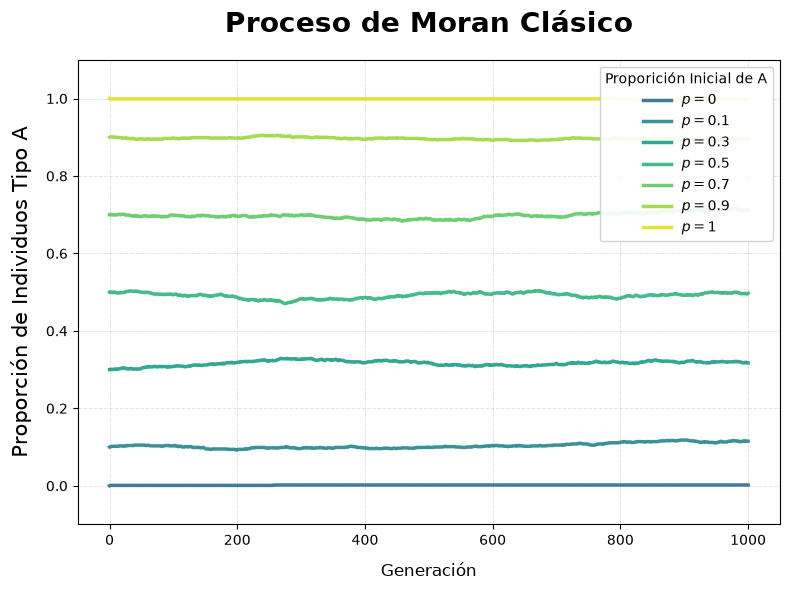

In [10]:
plot(tamanio=(8, 6), p=[0,0.1,0.3,0.5,0.7,0.9,1], 
     legendname="Proporición Inicial de A", tittle="Proceso de Moran Clásico", 
     xlabel="Generación", ylabel="Proporción de Individuos Tipo A", save_name="Moran_Process", process_func=moranProcess, N=1000, T=1000,g=0,poisson=False)

Acá no tenemos en cuenta nada más que la estocacidad del proceso, por lo que la proporción final de individuos de tipo A puede variar en cada ejecución además vemos que en promedio queda en la misma proporición inicial acorde a lo visto anteriormente sin oscilar demasiado dónde vemos menor oscilación es en los estados absorventes. 

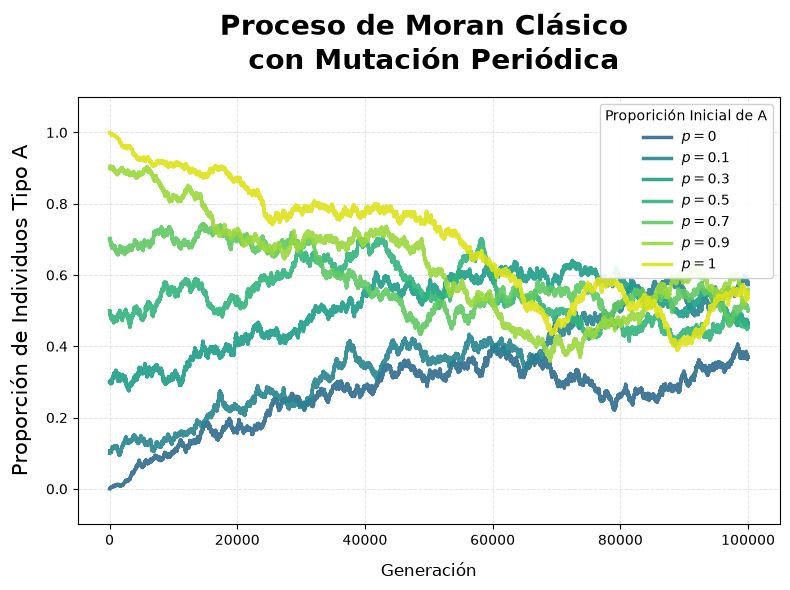

In [11]:
plot(tamanio=(8, 6), p=[0,0.1,0.3,0.5,0.7,0.9,1], 
     legendname="Proporición Inicial de A", tittle="Proceso de Moran Clásico \n con Mutación Periódica", 
     xlabel="Generación", ylabel="Proporción de Individuos Tipo A", save_name="Moran_Process_MPeriodico", 
     process_func=moranProcess, N=1000, T=100000,g=100,poisson=False)

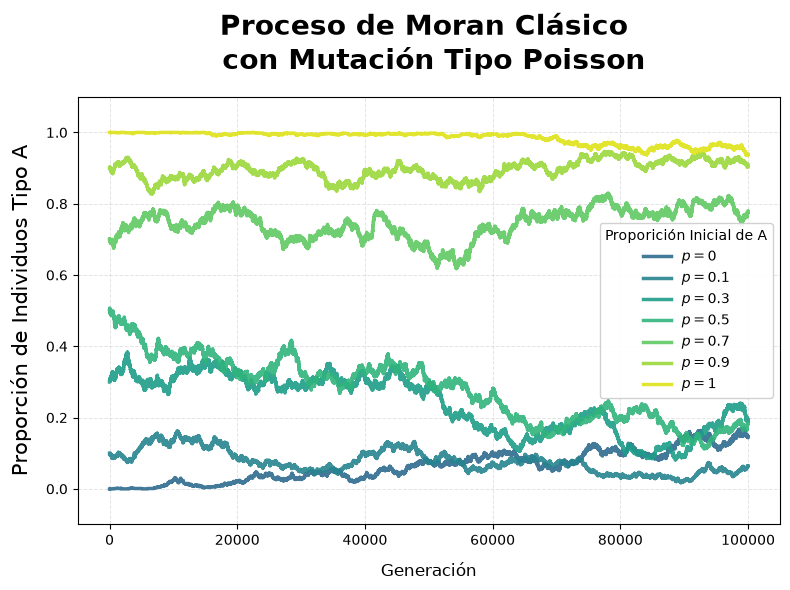

In [12]:
plot(tamanio=(8, 6), p=[0,0.1,0.3,0.5,0.7,0.9,1], 
     legendname="Proporición Inicial de A", tittle="Proceso de Moran Clásico \n con Mutación Tipo Poisson", 
     xlabel="Generación", ylabel="Proporción de Individuos Tipo A", save_name="Moran_Process_MPoisson", 
     process_func=moranProcess, N=1000, T=100000,g=0,poisson=True)

Introdujendo mutación vemos una tendencia a la coexistencia de los dos alelos, fijándose rápidamente utilizando la distribución de Poisson.

---

## Proceso de Moran Fitness Fijo

Acá vamos a simular un proceso de Moran utilizando pesos estadísticos dados por el fitness de A o fitness de B y va a morir de forma aleatoria cualquier individuo sin importar el fitness ni la depredación.


In [13]:
def populationDef(N,p):
    """
    Crea una población de tamaño N con una proporción inicial p de individuos de tipo A y (1-p) de tipo B.
    """
    if p == 0 : 
        population = ['B'] * (N-1) + ['A']
    elif p == 1 :
        population = ['A'] * (N-1) + ['B']
    else:
        population = ['A'] * int(p * N) + ['B'] * int((1 - p) * N)
    return population

In [14]:
def moranProcessFitness(N, p, T, g, poisson):
    """
    Simula un proceso de Moran para una población de tamaño N, con una proporción inicial p de individuos de tipo A y T generaciones.
    Devuelve la proporción final de individuos de tipo A después de T generaciones.
    """
    fit_a =  1+ s_a
    fit_b = 1+ s_b
    population = populationDef(N, p)
         
    history = []

    for t in range(T):
        
        
        reproducer = random.choices(
                    population,
                    weights=[fit_a if x == 'A' else fit_b for x in population])[0]

        to_die = random.choice(population) 
        population[population.index(to_die)] = reproducer 

        if g > 1  : #Asumimos que hay mutación
                    population = mutacionPeriodica(t,g,population)
        
        elif poisson: 
                    population = mutacionPoisson(population)
        

        history.append(population.count('A') / len(population))
    return round(population.count('A') / len(population), 1), history

x= moranProcessFitness(N=1000, p=0.5, T= 1000, g= 0,poisson=False)[0]
y= moranProcessFitness(N=1000, p=0.5, T= 1000, g= 7,poisson=False)[0]
z= moranProcessFitness(N=1000, p=0.5, T= 1000, g= 0,poisson=True)[0]

print(f"Proporción final de A sin mutación: {x}")
print(f"Proporción final de A con mutación de frecuencia: {y}")
print(f"Proporción final de A con mutación de Poisson: {z}")

Proporción final de A sin mutación: 0.6
Proporción final de A con mutación de frecuencia: 0.6
Proporción final de A con mutación de Poisson: 0.6


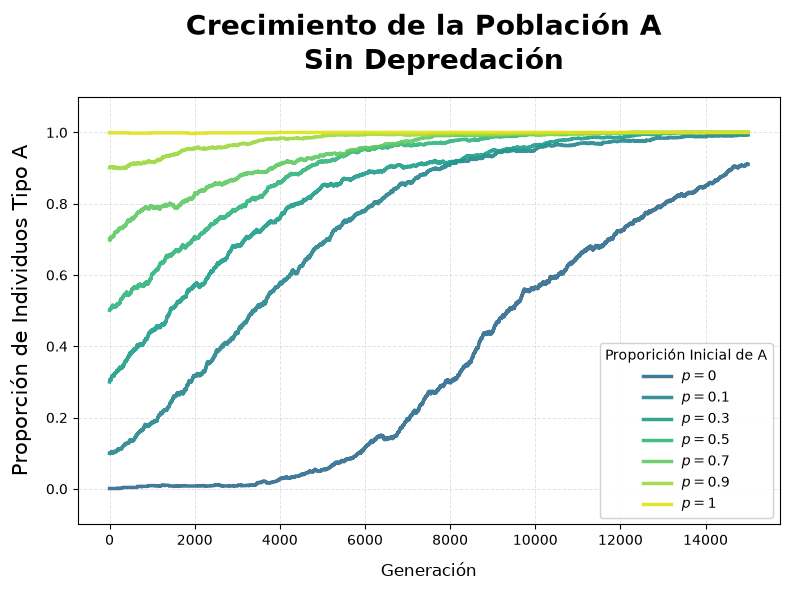

In [15]:
plot(tamanio=(8, 6), p=[0,0.1,0.3,0.5,0.7,0.9,1], 
     legendname="Proporición Inicial de A", tittle="Crecimiento de la Población A \n Sin Depredación", 
     xlabel="Generación", ylabel="Proporción de Individuos Tipo A", save_name="PM_FitFijo_Sin_Depredacion",
       process_func=moranProcessFitness, N=1000, T=15000, g=0, poisson= False)

Acá vemos que hay en promedio serán mayor porción de A's que de B's llendo a un estado de fijación de solo alelo tipo A sin importar que proporción inicial sea de cada individuo. Sin embargo, cuando iniciamos en una sola mutación de A  puede existir el caso que muera muy rápidamente el alelo raro. Tiene sentido pensar que a mayor belleza por parte de los peces macho guppies más serán elegidos por sus parejas.

---

Ahora introduciceremos la mutación dada por Poisson dentro de la población.

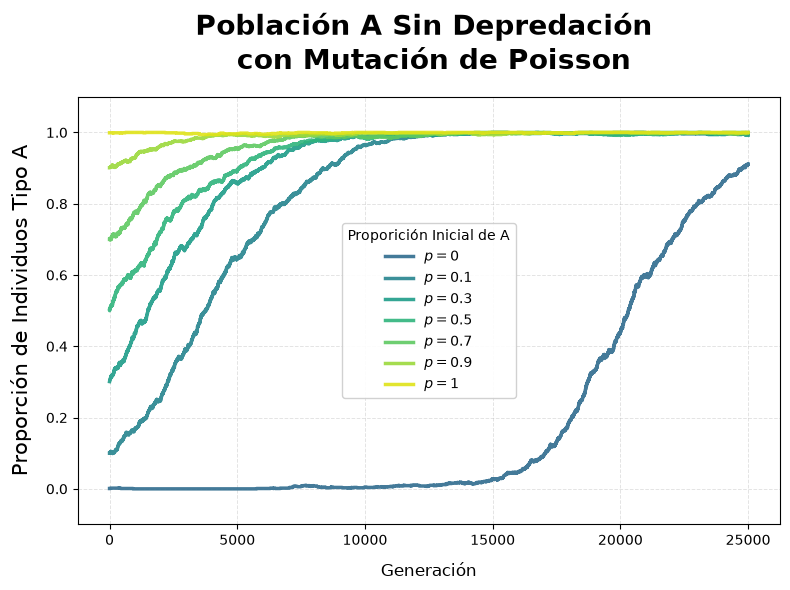

In [19]:
plot(tamanio=(8, 6), p=[0,0.1,0.3,0.5,0.7,0.9,1], 
    legendname="Proporición Inicial de A", tittle="Población A Sin Depredación \n con Mutación de Poisson", 
     xlabel="Generación", ylabel="Proporción de Individuos Tipo A", save_name="PM_FitFijo_Sin_Depredacion_MPoisson",
       process_func=moranProcessFitness, N=1000, T=25000, g=0, poisson= True)

Cuando introducimos la mutación de Poisson llegaremos a una mayoría para el fenotipo tipo en todos los casos sin importar con qué población inicial de A tenga.   A medida que hayan mayor cantidad de generaciones más fácilmente llegaremos a esa fijación de A



--- 

### Probaremos con el método Writh -Fisher

In [17]:
def Wright_FisherProcess(N, p, T):
    """
    Simula un proceso de Wright-Fisher para una población de tamaño N, con una proporción inicial p de individuos de tipo A y T generaciones.
    Devuelve la proporción final de individuos de tipo A después de T generaciones.
    """
    fit_a =  1+ s_a
    fit_b = 1+ s_b
    population = populationDef(N, p)
         
    history = []

    for _ in range(T):

        reproducers = []
        for _ in range(30):
            reproducer = random.choices(
                            population,
                            weights=[fit_a if x == 'A' else fit_b for x in population])[0]
                          
        muertos= []
        for _ in range(30):
              to_die = random.choice(population)
              muertos.append(population.index(to_die))

        for muerto in muertos:
            population[muerto] = reproducer 
        history.append(population.count('A') / len(population))
    return round(population.count('A') / len(population), 1), history

Wright_FisherProcess(N=1000, p=0.5, T= 1000)[0] 

1.0

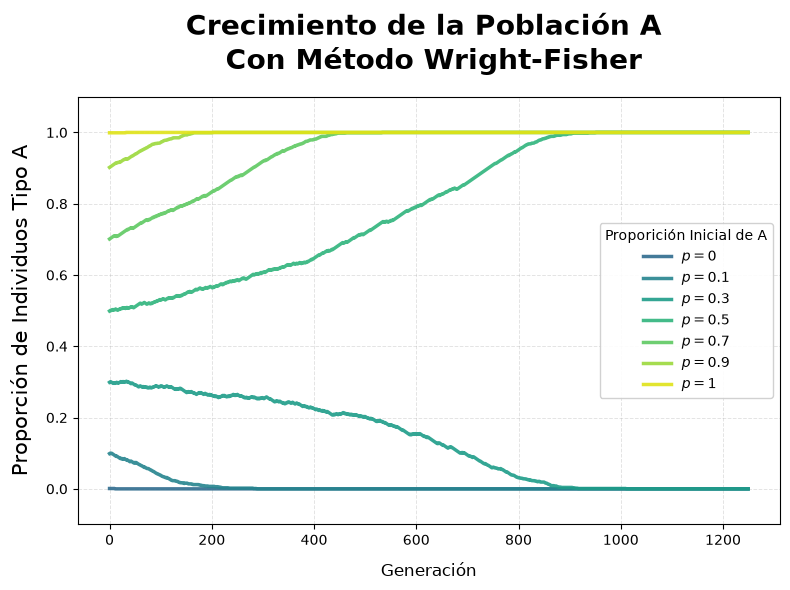

In [20]:
plot(tamanio=(8, 6), p=[0,0.1,0.3,0.5,0.7,0.9,1], 
    legendname="Proporición Inicial de A", tittle="Crecimiento de la Población A \n Con Método Wright-Fisher", 
     xlabel="Generación", ylabel="Proporción de Individuos Tipo A", save_name="FW_FitFijo_Sin_Depredacion",
       process_func=Wright_FisherProcess, N=1000, T=1250)

En este caso, vemos que caen a uno de los dos estados absorbentes dónde se fijará uno de los dos alelos. Además, cuando 0.37 vemos que existe posibilidad que vaya a fijarse B o que se fije A. Por encima de 0.37 siempre se fijará A y por debajo siempre se fijará B. 

---
### Proceso de Moran con Fitness y Tasa de Depredación

Además podríamos definir un fitness fijo para los individuos tipos A y B además de una tasa de depredación fija para cada uno acorde a que tan bellos o no sean.

In [ ]:
def moranProcessFitnessDepredacion(N, p, T,g,poisson):
    """
    Simula un proceso de Moran para una población de tamaño N, con una proporción inicial p de individuos de tipo A y T generaciones.
    Devuelve la proporción final de individuos de tipo A después de T generaciones.
    """
    fit_a = (1 + s_a) 
    fit_b = (1 + s_b) 
    population = populationDef(N, p)
    history = []
    for t in range(T):
        
        reproducer = random.choices(
                    population,
                    weights=[fit_a if x == 'A' else fit_b for x in population]
                )[0]
        to_die = random.choices(population, weights=[d_a if x == 'A' else d_b for x in population])[0]
        population[population.index(to_die)] = reproducer 
        if g > 1  : #Asumimos que hay mutación
            population = mutacionPeriodica(t,g,population)
                
        elif poisson: 
            population = mutacionPoisson(population)

        history.append(population.count('A') / len(population))
    return round(population.count('A') / len(population), 1), history

moranProcessFitnessDepredacion(N=1000, p=0.5, T= 1000,g=7,poisson=False)[0]

0.3

In [ ]:
fit_a = (1 + s_a) 
fit_b = (1 + s_b) 
print(fit_a/fit_b)

1.7475728155339805


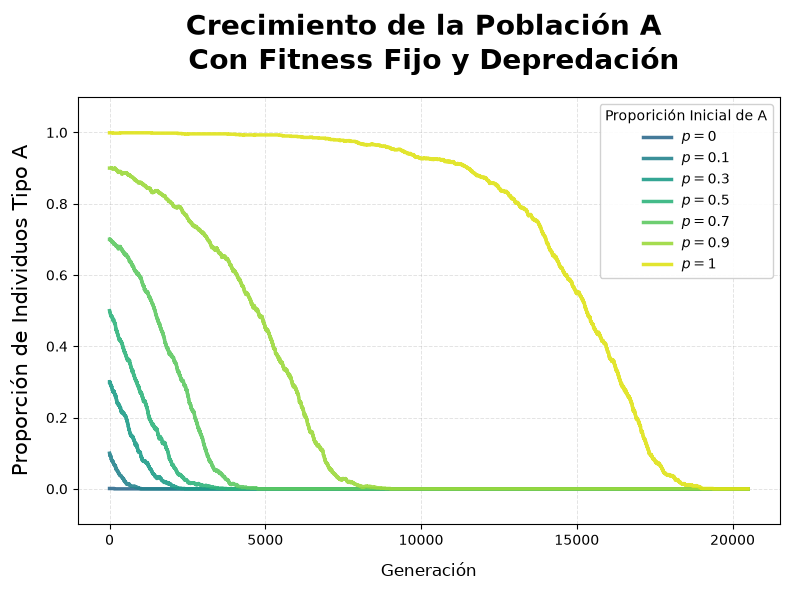

In [ ]:
plot(tamanio=(8, 6), p=[0,0.1,0.3,0.5,0.7,0.9,1], 
    legendname="Proporición Inicial de A", tittle="Crecimiento de la Población A \n Con Fitness Fijo y Depredación", 
     xlabel="Generación", ylabel="Proporción de Individuos Tipo A", save_name="PM_Fitness_Fijo_Con_Depredacion",
       process_func=moranProcessFitnessDepredacion, N=1000, T=20500,g=0 , poisson= False)

Acá vemos que hay en promedio serán menor porción de A's que de B's llendo a un estado absorvente que será sin alelo tipo A. Dónde se ve con claridad una desventaja  de depredación para aquellos peces que son más atractivos para los depredadores.

---

### Proceso de Moran con Fitness y Tasa de Depredación Dependiendo de la Frecuencia.

Ahora el fitness dependerá plenamente de la frecuencia del gen en la población, es decir, el fitness depende de la frecuencia y la facilidad en la que se los comen también. 
Ya se encuentran en un estado más vulnerable si hay demasiados de ellos porque en cardumen llaman mucho la atención de los depredadores además si hay poca frecuencia de estos habrá mayor facilidad de reproducción porque llaman la atención de las hembras. 

In [ ]:
def moranProcessFreqFitness(N, p, T):
    """
    Simula un proceso de Moran para una población de tamaño N, con una proporción inicial p de individuos de tipo A y T generaciones.
    Devuelve la proporción final de individuos de tipo A después de T generaciones.
    """
    population = population(N, p)
    p0 = p
    history = [p0]

    for _ in range(T):
        # fitness dependiente de la frecuencia
        fit_a_freq =  s_a/ (1+p0) 
        fit_b_freq =  s_b  

        # probabilidad de morir por tipo
        die_a_freq = d_a * p0
        die_b_freq = d_b * (1 - p0)

        to_die = random.choices(
            population,
            weights=[die_a_freq if x == 'A' else die_b_freq for x in population]
        )[0]

        reproducer = random.choices(
            population,
            weights=[fit_a_freq if x == 'A' else fit_b_freq for x in population]
        )[0]

        population[population.index(to_die)] = reproducer
        p0 = population.count('A') / len(population)
        history.append(p0)

    return round(p0, 3), history

moranProcessFreqFitness(N=1000, p=0.5, T=1000)[0]

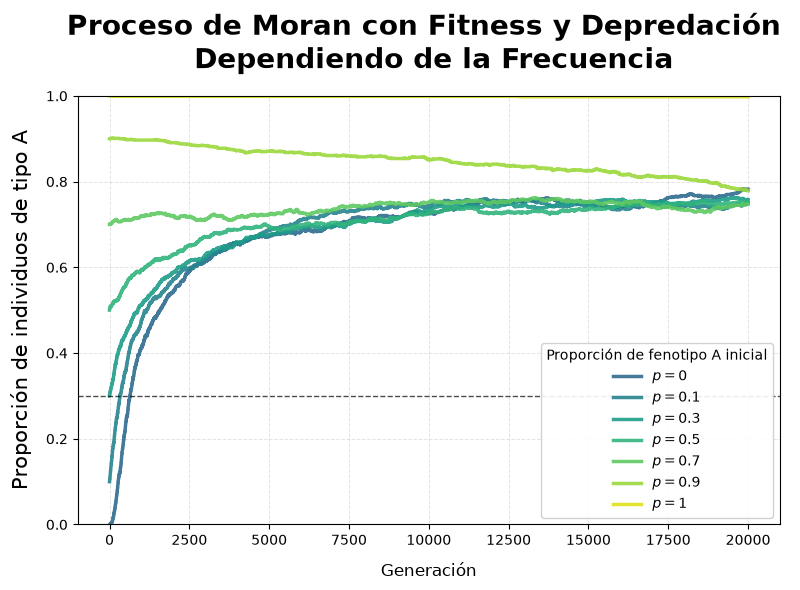

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

p = [0, 0.1, 0.3, 0.5, 0.7, 0.9, 1]
for prop, color in zip(p, colors):
    generaciones = moranProcessFreqFitness(N=1000, p=prop, T=20000)[1]
    ax.plot( generaciones, label=fr'$p = {prop}$', color=color, linewidth=2.5, alpha=0.9)

ax.set_xlabel('Generación', fontsize=12, labelpad=10)
ax.set_ylabel('Proporción de individuos de tipo A', fontsize=15, labelpad=10)
ax.set_title( 'Proceso de Moran con Fitness y Depredación \n Dependiendo de la Frecuencia', fontsize=20, fontweight='bold', pad=20)
ax.set_ylim(0, 1)
ax.axhline(0.3, color='black', linestyle='--', linewidth=1, alpha=0.7)
ax.grid( True, linestyle='--', linewidth=0.7, alpha=0.35)
ax.tick_params(axis='both', labelsize=10)
ax.legend( 
    title='Proporción de fenotipo A inicial',
    fontsize=10,
    title_fontsize=10,
    loc='best',
    frameon=True,
    fancybox=True,
    framealpha=0.9
)


plt.tight_layout()
plt.savefig('../Gráficas/PM_FitnessDepredacion_Frecuencia.png')
plt.show()

Teniendo en cuenta que tendremos depredación y apareamiento acorde a un fitness móvil que depende de la frecuencia. Vemos que habrá mayor población de A's que de B's fijándose en un más o menos de 0.2 dónde es muy relevante desde que proporción de A's para 0.1 se fijará alrededor de 5000 generaciones, para 0.3 y 0.5 será alrededor de 2000 generaciones, para 0.7 será alrededor de 3000 generaciones y para 0.9 será luego de las 6000 generaciones.

--- 

Ahora voy a introducir un fetonotipo que me pueda llevar a cabo una categoría de un pez "activo" (alelo C) y uno que sea menos activo (alelo D). Esto ha sido una constante en algunos papers que hablan sobre una relación de vigurosidad y facilidad de salir intactos contra depredadores. Por otro lado, hay algunos que relacionan las manchas naranajas las cuáles podrían mostrar vigurosidad en algunos peces. Podríamos hacer de forma estocástica la selección de los peces más vigurosos dándole más peso a los que tienen el fenotipo A. 


In [ ]:
def poblacionvigorosa(p, v_a, v_b, N):
    """
    Genera una población de tamaño N con una proporción inicial p de individuos de tipo A y (1-p) de tipo B.
    Cada individuo tiene una probabilidad v de ser vigoroso.
    Devuelve la población generada. 
    """
    population = ['A'] * int(p * N) + ['B'] * int((1 - p) * N) 
    for i in range(len(population)):
        if population[i] == 'A':
            if random.random() < v_a:
                population[i] = 'AC'
            else: 
                population[i] = 'AD'

        else:
            if random.random() < v_b:
                population[i] = 'BC'
            else: 
                population[i] = 'BD'
    return population

p= 0.5
v_a = 0.6 # La prob de que un individuo A sea vigoroso hay que revisarlo
v_b = 0.1 # La prob de que un individuo B sea vigoroso hay que revisarlo
poblacion= poblacionvigorosa(p, v_a, v_b, N=1000)
print(f"Para una población de {len(poblacion)} tenemos que:")
print("La población de individuos de tipo A y B con vigor es: ", (poblacion.count('AC') + poblacion.count('BC'))/len(poblacion))
print("La población de individuos de tipo A y B sin vigor es: ", (poblacion.count('AD') + poblacion.count('BD'))/len(poblacion))

Para una población de 1000 tenemos que:
La población de individuos de tipo A y B con vigor es:  0.332
La población de individuos de tipo A y B sin vigor es:  0.668


In [ ]:
def actualizarProporciones(history, population):
    """
     Actualiza el historial con las proporciones de cada estrategia.
    """
    total = len(population)
    for tipo in history:
        proporcion = population.count(tipo) / total
        history[tipo].append(proporcion)
    return history


def obtenerPesos(population, valores):
    """
    Asigna a cada individuo de la población el peso
    correspondiente a su tipo.

    Esta función evita repetir el mismo bloque de código
    cada vez que necesitamos calcular pesos de reproducción
    o de muerte.

    """
    return [valores[individuo] for individuo in population]


def fitnessDinamico(p0, p1, s_a, s_b, d_a, d_b, p_v):
    """
    Calcula el fitness de cada tipo de individuo.

    El fitness depende de la proporción actual de individuos
    tipo A y tipo B. Por eso se recalcula en cada iteración.

    """

    # Fitness base de cada tipo.
    fitness_A = 1 + s_a * p1 - d_a * p0
    fitness_B = 1 + s_b * p0 - d_b * p1

    # Los individuos llamativos tienen un efecto distinto
    fit_AC = fitness_A * (1 + p_v)  # A activo
    fit_AD = fitness_A * (1 )  # A pasivo

    fit_BC = fitness_B * (1 + p_v)  # B activo
    fit_BD = fitness_B * (1 )  # B pasivo

    return {"AC": max(0,fit_AC), "AD": max(0,fit_AD), "BC": max(0,fit_BC), "BD": max(0,fit_BD)}


def probMuerte(p0,p1,d_a, d_b, p_v):
    """
    Calcula la probabilidad de muerte de cada tipo.

    La muerte depende de la tasa base del efecto
    de la visibilidad y de la actividad del individuo. 
    """

    # Tipo A
    die_AC = d_a * (1 - p_v)*p0  # A activo: menor mortalidad
    die_AD = d_a *p0  # A pasivo: mayor mortalidad

    # Tipo B
    die_BC = d_b * (1 - p_v)*p1  # B activo: menor mortalidad
    die_BD = d_b *p1  # B pasivo: mayor mortalidad

    return {"AC": max(0, die_AC), "AD": max(0, die_AD), "BC": max(0, die_BC), "BD": max(0, die_BD)}


p_v=0.5

def moranProcessFreqFitnessVigor(N, p, T,v_a,v_b):
    """
    Simula un proceso de Moran con fitness dinámico y vigor.

    En cada iteración:

    1. Se calcula el fitness de cada tipo.
    2. Se calcula la probabilidad de muerte de cada tipo.
    3. Se selecciona un individuo para morir.
    4. Se selecciona un individuo para reproducirse.
    5. El individuo que muere es reemplazado por una copia
       del individuo que se reproduce.
    6. Se actualizan las proporciones de cada tipo.

    """
    population = poblacionvigorosa(p, v_a, v_b, N)
    history = {"AC": [], "AD": [], "BC": [], "BD": []}
    actualizarProporciones(history, population)


    for _ in range(T):

        p0 = sum(individuo in ['AC', 'AD'] for individuo in population) / len(population)
        p1 = 1 - p0

        fit = fitnessDinamico( p0,p1, s_a, s_b, d_a, d_b, p_v)
        die = probMuerte(p0,p1,d_a, d_b, p_v)

        weights_die = obtenerPesos(population, die)
        to_die = random.choices( population,
            weights=weights_die, k=1 )[0]
    
        weights_repro = obtenerPesos(population, fit)
        reproducer = random.choices(population,
            weights=weights_repro, k=1)[0]

        #actualizacion
        index_to_die = population.index(to_die)
        population[index_to_die] = reproducer


        actualizarProporciones(history, population)

    p0_final = (population.count("AC") + population.count("AD")) / N

    return round(p0_final, 3), history


moranProcessFreqFitnessVigor(N=1000, p=0.5, T=1000, v_a=0.6, v_b=0.1)[0]

0.42

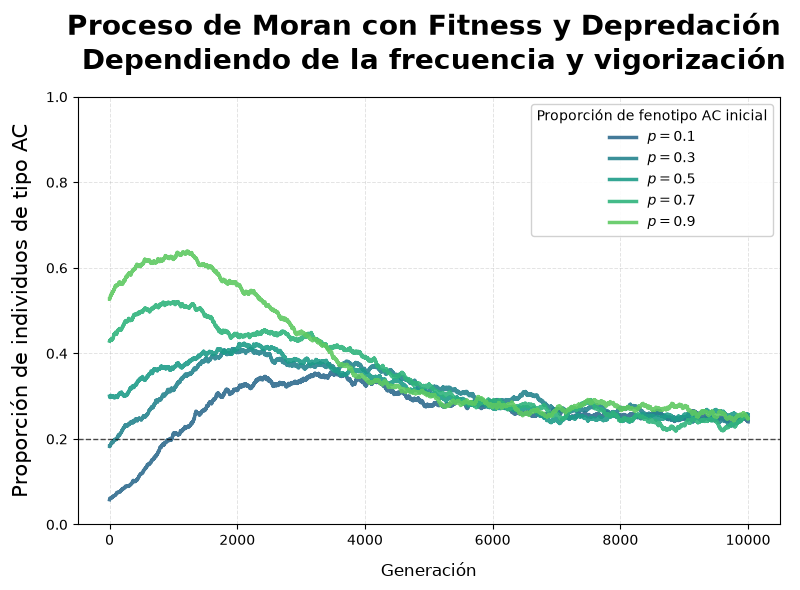

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

p = [0.1, 0.3, 0.5, 0.7, 0.9]
for prop, color in zip(p, colors):
    generaciones = moranProcessFreqFitnessVigor(N=1000, p=prop, T=10000, v_a=0.6, v_b=0.1)[1]
    ax.plot( generaciones["AC"], label=fr'$p = {prop}$', color=color, linewidth=2.5, alpha=0.9)

ax.set_xlabel('Generación', fontsize=12, labelpad=10)
ax.set_ylabel('Proporción de individuos de tipo AC', fontsize=15, labelpad=10)
ax.set_title( 'Proceso de Moran con Fitness y Depredación \n Dependiendo de la frecuencia y vigorización', fontsize=20, fontweight='bold', pad=20)
ax.set_ylim(0, 1)
ax.axhline(0.2, color='black', linestyle='--', linewidth=1, alpha=0.7)
ax.grid( True, linestyle='--', linewidth=0.7, alpha=0.35)
ax.tick_params(axis='both', labelsize=10)
ax.legend( 
    title='Proporción de fenotipo AC inicial',
    fontsize=10,
    title_fontsize=10,
    loc='best',
    frameon=True,
    fancybox=True,
    framealpha=0.9
)


plt.tight_layout()
plt.savefig('../Gráficas/PM_FitnessDepredacion_freq_y_vigo.png')
plt.show()

In [ ]:
df = pd.DataFrame(moranProcessFreqFitnessVigor(N=1000, p=0.5, T=10000, v_a=0.6, v_b=0.1)[1])
df['A_total'] = df['AC'] + df['AD']
df['B_total'] = df['BC'] + df['BD']
print(df.head())

      AC     AD     BC     BD  A_total  B_total
0  0.314  0.186  0.053  0.447    0.500    0.500
1  0.314  0.185  0.053  0.448    0.499    0.501
2  0.314  0.184  0.054  0.448    0.498    0.502
3  0.315  0.183  0.054  0.448    0.498    0.502
4  0.316  0.183  0.054  0.447    0.499    0.501


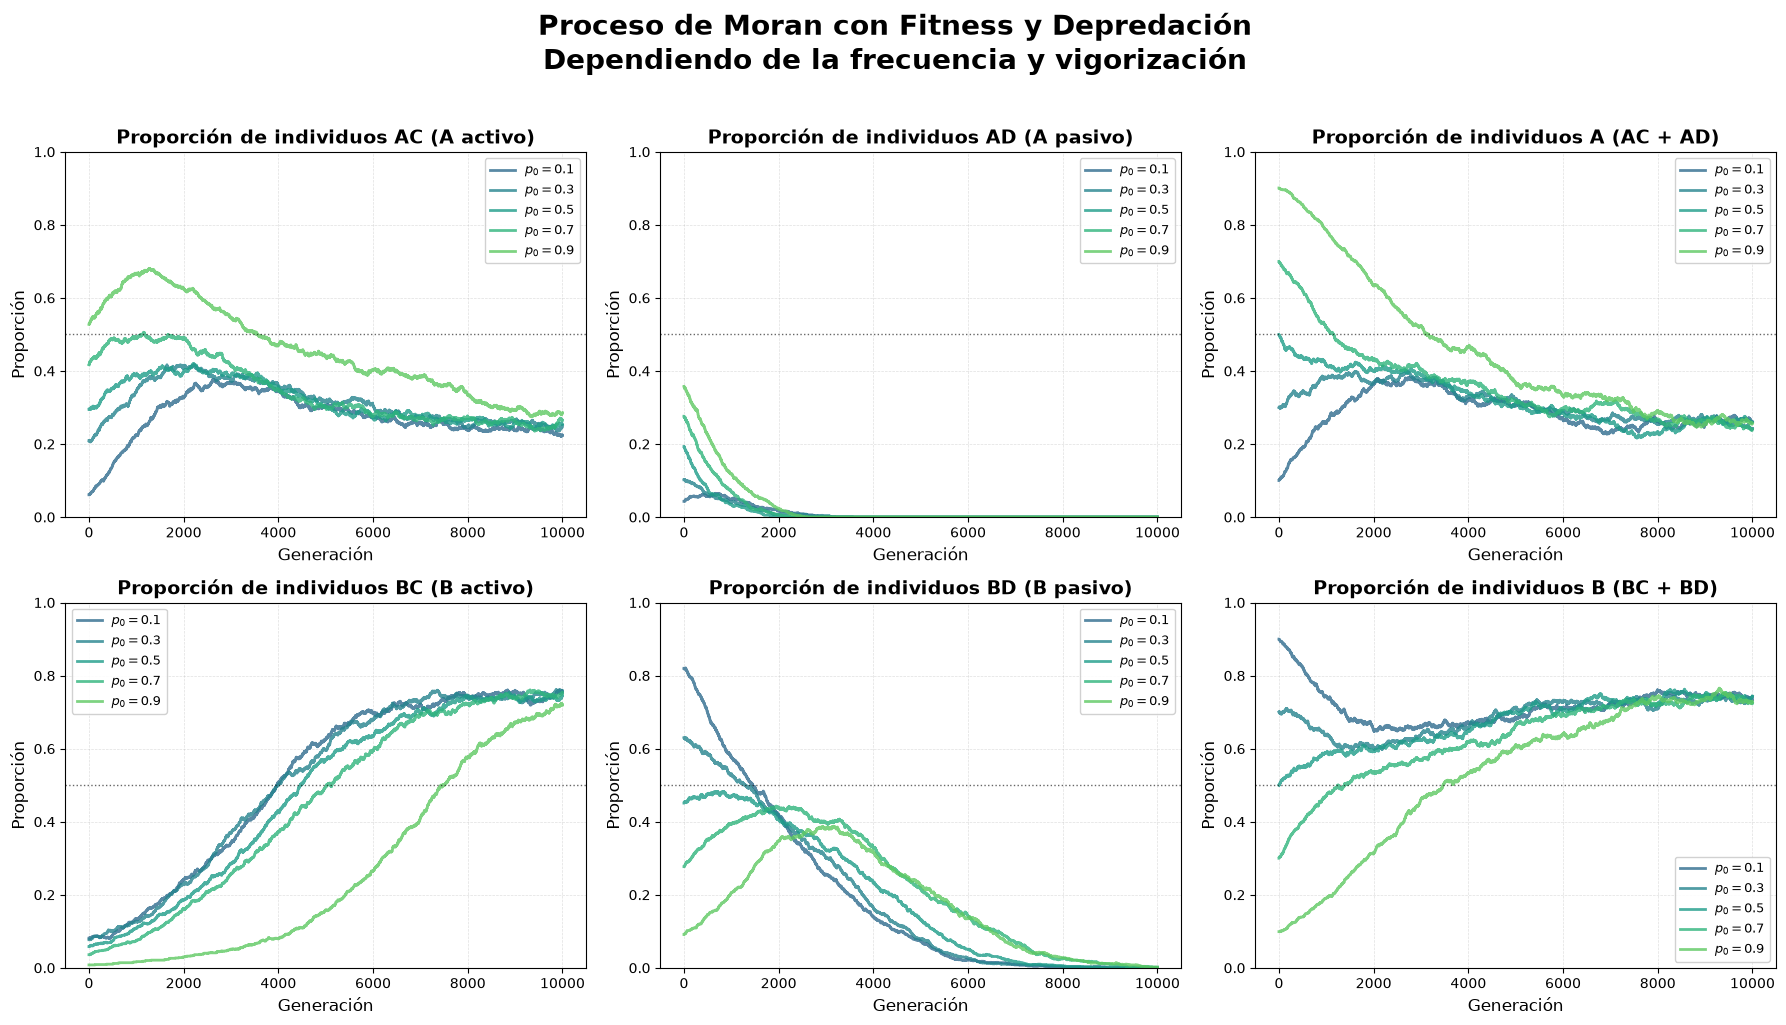

In [ ]:
fenotipos = {
    'AC': 'Proporción de individuos AC (A activo)',
    'AD': 'Proporción de individuos AD (A pasivo)',
    'A_total': 'Proporción de individuos A (AC + AD)',
    'BC': 'Proporción de individuos BC (B activo)',
    'BD': 'Proporción de individuos BD (B pasivo)',
    'B_total': 'Proporción de individuos B (BC + BD)'
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, (fenotipo, titulo) in enumerate(fenotipos.items()):
    ax = axes[idx]
    p = [0.1, 0.3, 0.5, 0.7, 0.9]
    for prop, color in zip(p, colors):
        df = pd.DataFrame(moranProcessFreqFitnessVigor(N=1000, p=prop, T=10000, v_a=0.6, v_b=0.1)[1])
        df['A_total'] = df['AC'] + df['AD']
        df['B_total'] = df['BC'] + df['BD']

        ax.plot(df[fenotipo], label=fr'$p_0 = {prop}$', color=color, linewidth=2, alpha=0.8)
    
    ax.set_xlabel('Generación', fontsize=12)
    ax.set_ylabel('Proporción', fontsize=12)
    ax.set_title(titulo, fontsize=14, fontweight='bold')
    ax.set_ylim(0, 1)
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.4)
    ax.axhline(0.5, color='black', linestyle=':', linewidth=1, alpha=0.6)
    ax.tick_params(labelsize=10)
    ax.legend(loc='best', fontsize=9, framealpha=0.9)

plt.suptitle(
    'Proceso de Moran con Fitness y Depredación\nDependiendo de la frecuencia y vigorización',
    fontsize=20,
    fontweight='bold',
    y=1.02
)
plt.tight_layout()
plt.savefig('../Gráficas/PM_FitnessDepredacion_freq_y_vigoTODOS.png', dpi=300, bbox_inches='tight')
plt.show()

---

### Matriz de Markov
Ahora, para hacerlo más chévere, voy a construir una matriz de probabilidades/Markov, que tendrá un tamaño de (N+1) × (N+1), donde N es el tamaño de la población. Cada elemento de esta matriz representará la probabilidad de transición entre estados, es decir, la probabilidad de que el número de individuos de tipo A pase de un valor i a un valor i-1 (disminuya en uno), i+1 (aumente en uno) o se mantenga en i, para todos los estados intermedios donde 0 < i < N. Los estados extremos i=0 e i=N son considerados absorbentes, lo que significa que una vez que la población alcanza estos estados (todos individuos de tipo B o todos de tipo A, respectivamente), permanece en ellos con probabilidad 1.

In [ ]:
def matrix(N,  d_a, d_b, s_a, s_b):
    """
    Construye la matriz de transición para un proceso de Moran con selección y deriva.
    N: tamaño de la población
    s_a: ventaja selectiva del tipo A
    s_b: ventaja selectiva del tipo B
    d_a: deriva del tipo A
    d_b: deriva del tipo B
    """
    T_matrix = np.zeros((N+1, N+1))
    T_matrix[0, 0] = 1; T_matrix[N, N] = 1     # Estados absorbentes
    
    for i in range(1, N):
        freq_a = i / N
        freq_b = 1 - freq_a
        
        #Facilidad de reproducción y muerte acorde a la frecuencia actual
        fit_a = 1 + s_a * freq_a - d_a * freq_a
        fit_b = 1 + s_b * freq_b - d_b * freq_b
        total_fit = fit_a + fit_b
        die_a = d_a * freq_a
        die_b = d_b * freq_b

        T_matrix[i, i-1] = round(die_a * (fit_b / total_fit), 5)
        T_matrix[i, i+1] = round(die_b * (fit_a / total_fit), 5)
        T_matrix[i, i] = round(1 - T_matrix[i, i-1] - T_matrix[i, i+1], 5)
    
    return T_matrix

T = matrix(N= 10, d_a=0.78, d_b=0.22, s_a=0.8, s_b=0.03)